In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')


In [ ]:
end = datetime.now()
start = datetime(end.year-10, end.month, end.day)
stock = 'BTC-USD'
stock_data = yf.download(stock, start=start, end = end)

/tmp/ipython-input-3893172020.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(stock, start=start, end = end)
[*********************100%***********************]  1 of 1 completed


In [ ]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2015-11-27,358.041992,363.588989,347.869995,351.860992,55179100
2015-11-28,357.381012,359.536011,352.171997,357.140991,36816600
2015-11-29,371.294006,371.938995,355.665985,357.471985,40409300
2015-11-30,377.321014,382.363007,370.382996,371.437012,71701600
2015-12-01,362.488007,378.931000,356.562988,377.414001,60452200


In [ ]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-11-23,86805.007812,88038.468750,84641.773438,84648.609375,58083435576
2025-11-24,88270.562500,89206.335938,85272.195312,86798.773438,74433896110
2025-11-25,87341.890625,88457.335938,86131.429688,88269.960938,64837343545
2025-11-26,90518.367188,90581.156250,86316.898438,87345.585938,66496301869
2025-11-27,91492.460938,91804.242188,90193.335938,90507.968750,72934735872


In [ ]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,3654.000000,3654.000000,3654.000000,3654.000000,3.654000e+03
mean,29439.104493,30010.144487,28784.862298,29415.340636,2.396910e+10
std,31679.903090,32202.798549,31092.750872,31667.680338,2.281360e+10
min,357.381012,359.536011,347.869995,351.860992,2.851400e+07
25%,6292.130127,6399.207397,6193.560181,6284.652466,5.046041e+09
50%,16674.648438,16911.009766,16433.568359,16658.704102,1.991381e+10
75%,44409.875977,45774.635742,43389.945312,44355.677734,3.492028e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [ ]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,BTC-USD,3654.0,2.943910e+04,3.167990e+04,3.573810e+02,6.292130e+03,1.667465e+04,4.440988e+04,1.247525e+05
High,BTC-USD,3654.0,3.001014e+04,3.220280e+04,3.595360e+02,6.399207e+03,1.691101e+04,4.577464e+04,1.261981e+05
Low,BTC-USD,3654.0,2.878486e+04,3.109275e+04,3.478700e+02,6.193560e+03,1.643357e+04,4.338995e+04,1.231960e+05
Open,BTC-USD,3654.0,2.941534e+04,3.166768e+04,3.518610e+02,6.284652e+03,1.665870e+04,4.435568e+04,1.247521e+05
Volume,BTC-USD,3654.0,2.396910e+10,2.281360e+10,2.851400e+07,5.046041e+09,1.991381e+10,3.492028e+10,3.509679e+11


In [ ]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3654 entries, 2015-11-27 to 2025-11-27
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   3654 non-null   float64
 1   (High, BTC-USD)    3654 non-null   float64
 2   (Low, BTC-USD)     3654 non-null   float64
 3   (Open, BTC-USD)    3654 non-null   float64
 4   (Volume, BTC-USD)  3654 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 171.3 KB


In [ ]:
stock_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [ ]:
#close price data
closing_price = stock_data['Close']

In [ ]:
closing_price = stock_data['Close']
closing_price['Close']

Ticker,BTC-USD
Date,
2015-11-27,358.041992
2015-11-28,357.381012
2015-11-29,371.294006
2015-11-30,377.321014
2015-12-01,362.488007
...,...
2025-11-23,86805.007812
2025-11-24,88270.562500
2025-11-25,87341.890625


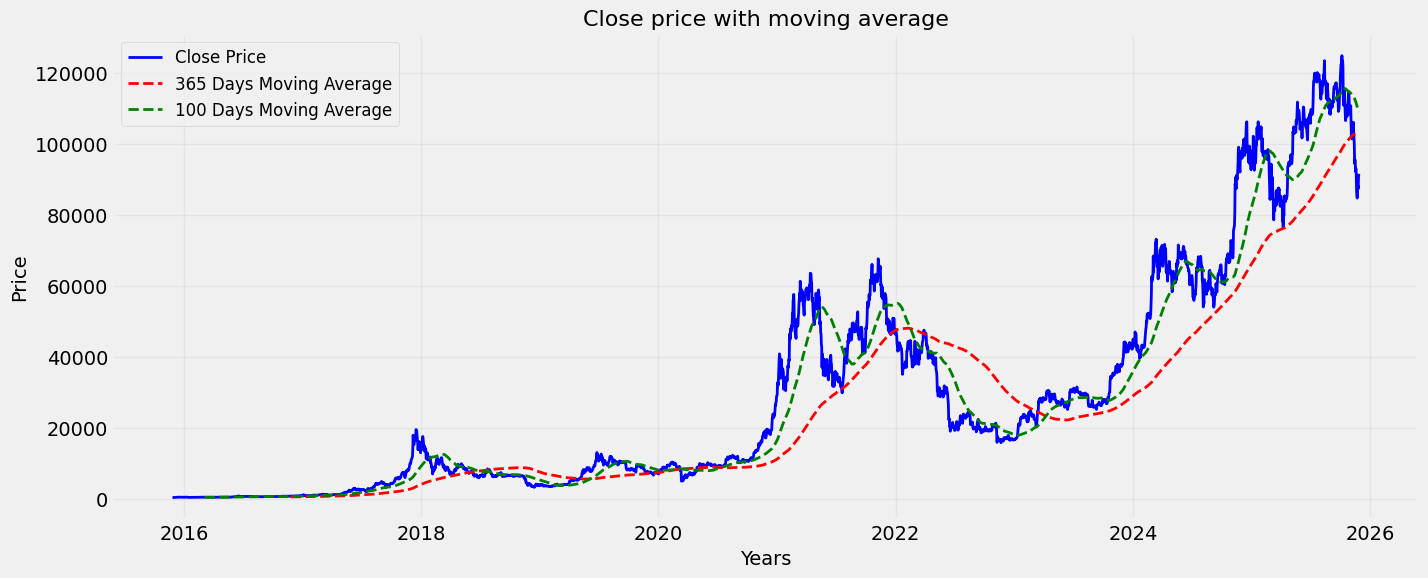

In [ ]:
#Plot closing price with enchacement
# Calculate moving averages
closing_price = stock_data['Close'].copy() # Create a copy to avoid SettingWithCopyWarning
closing_price['MA_365'] = closing_price['BTC-USD'].rolling(window=365).mean()
closing_price['MA_100'] = closing_price['BTC-USD'].rolling(window=100).mean()

plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['BTC-USD'], label = 'Close Price', color = 'blue', linewidth =2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Days Moving Average', color = 'red', linestyle ="--", linewidth =2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Days Moving Average', color = 'green',linestyle ="--", linewidth =2)

plt.title("Close price with moving average", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [ ]:
#Moving Average
temp_data = [10,20,30,40,50,60,70,80,90,100]
# moving average for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[1:6])/5)




40.0


In [ ]:
df1 = pd.DataFrame(temp_data)


In [ ]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [ ]:
for i in range (2015, 2025):
  print (i, list(stock_data.index.year).count(i))

2015 35
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365
2024 366


In [ ]:
# LSTM-> long short term memory
# scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(closing_price['BTC-USD'].values.reshape(-1,1))

In [ ]:
len(scaled_data)

3654

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [ ]:
# Prepare data for lstm
x_data = []
y_data = []
base_days =100
for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days: i])
    y_data.append(scaled_data[i])
x_data = np.array(x_data)
y_data = np.array(y_data)

In [ ]:
# Split into train and test sets
train_size = int(len(x_data)* 0.9)
x_train , y_train = x_data[:train_size], y_data[:train_size]
x_test , y_test = x_data[train_size:], y_data[train_size:]

In [ ]:
model = Sequential([
    LSTM(units = 128, return_sequences = True, input_shape = (x_train.shape[1], 1)),
    LSTM(units = 64, return_sequences = False),
    Dense(units = 25),
    Dense(units = 1)
])
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train, y_train, batch_size = 5, epochs = 10)

Epoch 1/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 48s 71ms/step - loss: 0.0022
Epoch 2/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 46s 72ms/step - loss: 2.9996e-04
Epoch 3/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - loss: 2.1381e-04
Epoch 4/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - loss: 1.8009e-04
Epoch 5/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - loss: 1.6087e-04
Epoch 6/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - loss: 1.1318e-04
Epoch 7/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - loss: 1.1941e-04
Epoch 8/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - loss: 1.2885e-04
Epoch 9/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - loss: 1.2563e-04
Epoch 10/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - loss: 1.1130e-04


In [ ]:
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [ ]:
inv_y_test

array([[ 99923.3359375],
       [101236.015625 ],
       [ 97432.71875  ],
       [ 96675.4296875],
       [101173.03125  ],
       [100043.       ],
       [101459.2578125],
       [101372.96875  ],
       [104298.6953125],
       [106029.71875  ],
       [106140.6015625],
       [100041.5390625],
       [ 97490.953125 ],
       [ 97755.9296875],
       [ 97224.7265625],
       [ 95104.9375   ],
       [ 94686.2421875],
       [ 98676.09375  ],
       [ 99299.1953125],
       [ 95795.515625 ],
       [ 94164.859375 ],
       [ 95163.9296875],
       [ 93530.2265625],
       [ 92643.2109375],
       [ 93429.203125 ],
       [ 94419.7578125],
       [ 96886.875    ],
       [ 98107.4296875],
       [ 98236.2265625],
       [ 98314.9609375],
       [102078.0859375],
       [ 96922.703125 ],
       [ 95043.5234375],
       [ 92484.0390625],
       [ 94701.453125 ],
       [ 94566.59375  ],
       [ 94488.4375   ],
       [ 94516.5234375],
       [ 96534.046875 ],
       [100504.4921875],


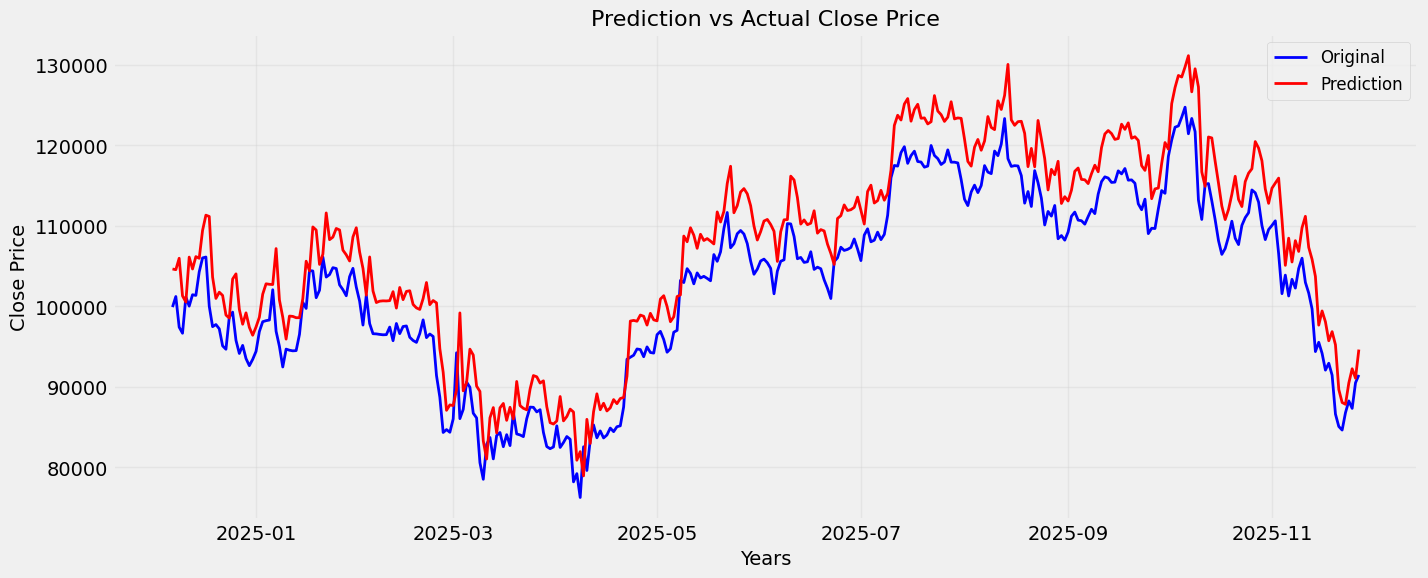

In [ ]:
plotting_data = pd.DataFrame(
    {
        'Original': inv_y_test.flatten(),
        'Prediction': inv_predictions.flatten(),
    }, index = closing_price.index[train_size + base_days:]
)

plt.figure(figsize = (15, 6))
plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original', color = 'blue', linewidth =2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction', color = 'red',  linewidth =2)

plt.title("Prediction vs Actual Close Price", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()


In [ ]:
# Predict future days
last_100  = scaled_data[-100:].reshape(1, -1, 1)
future_predictions=[]
for _ in range(10):
    next_days = model.predict(last_100)
    future_predictions.append(scaler.inverse_transform(next_days))
    last_100 = np.append(last_100[:, 1:, :], next_days.reshape(1, 1, -1), axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


In [ ]:
future_predictions

[array([[95752.36]], dtype=float32),
 array([[100567.1]], dtype=float32),
 array([[106062.43]], dtype=float32),
 array([[112209.36]], dtype=float32),
 array([[119038.48]], dtype=float32),
 array([[126614.39]], dtype=float32),
 array([[135025.5]], dtype=float32),
 array([[144375.97]], dtype=float32),
 array([[154780.34]], dtype=float32),
 array([[166358.42]], dtype=float32)]

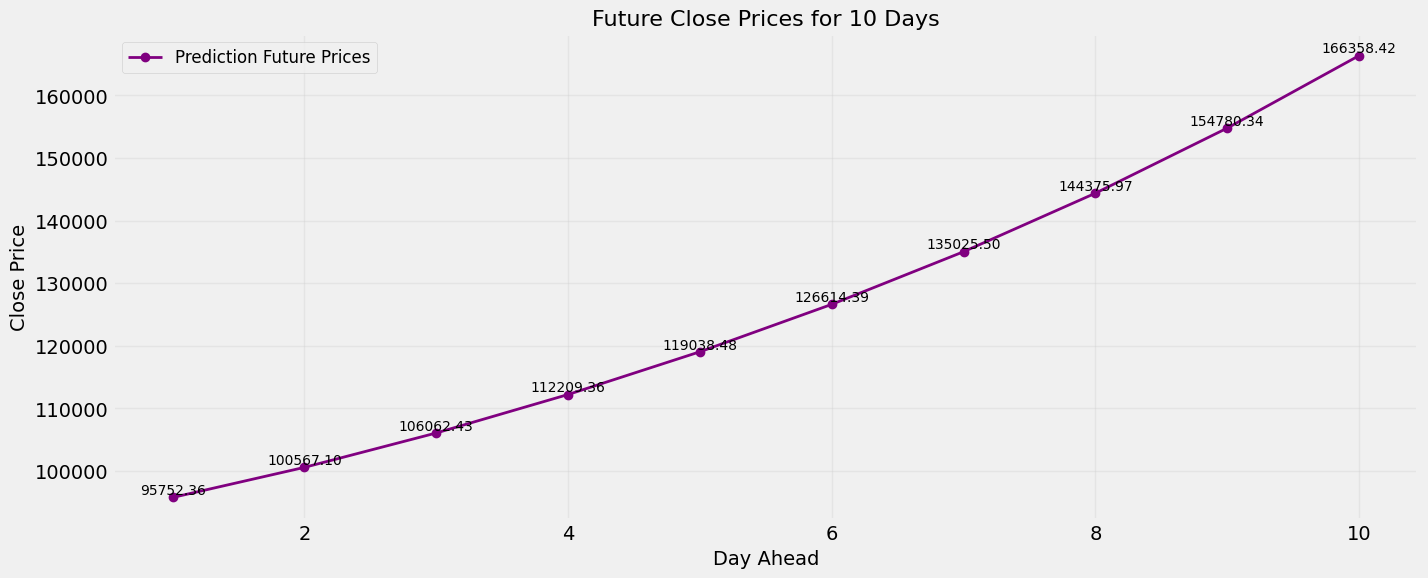

In [ ]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize = (15, 6))
plt.plot(range(1, 11), future_predictions, marker="o" ,label = 'Prediction Future Prices', color = 'purple', linewidth =2)

for i, val in enumerate(future_predictions):
    plt.text(i+1,val,  f'{val:.2f}', fontsize = 10, ha = 'center', va = 'bottom', color='black')

plt.title("Future Close Prices for 10 Days", fontsize = 16)
plt.xlabel("Day Ahead", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [ ]:
model.save("model.keras")